In [1]:
import pandas as pd
import numpy as np

### Load Ratings

In [2]:
ratings=pd.read_csv('ml-100k/u.data',
                   sep='\t',
                   names=['user_id','movie_id','rating','timestamp'])

### Load Movie info

In [4]:
movies=pd.read_csv(
    'ml-100k/u.item',
    sep="|",
    encoding="latin-1",
    header=None
)

In [5]:
movies=movies[[0,1]+list(range(5,24))]
movies.columns=[
    "movie_id","title",
    "unknown","Action","Adventure","Animation","Children","Comedy","Crime",
    "Documentary","Drama","Fantasy","Film-Noir","Horror","Musical","Mystery",
    "Romance","Sci-Fi","Thriller","War","Western"
]

### Load User Data

In [7]:
users=pd.read_csv(
    'ml-100k/u.user',
    sep="|",
    names=['user_id','age','gender','occupation','zip_code']
)

### data visualisation

In [8]:
movies.head()

,movie_id,title,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),0,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


In [9]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   movie_id     1682 non-null   int64 
 1   title        1682 non-null   object
 2   unknown      1682 non-null   int64 
 3   Action       1682 non-null   int64 
 4   Adventure    1682 non-null   int64 
 5   Animation    1682 non-null   int64 
 6   Children     1682 non-null   int64 
 7   Comedy       1682 non-null   int64 
 8   Crime        1682 non-null   int64 
 9   Documentary  1682 non-null   int64 
 10  Drama        1682 non-null   int64 
 11  Fantasy      1682 non-null   int64 
 12  Film-Noir    1682 non-null   int64 
 13  Horror       1682 non-null   int64 
 14  Musical      1682 non-null   int64 
 15  Mystery      1682 non-null   int64 
 16  Romance      1682 non-null   int64 
 17  Sci-Fi       1682 non-null   int64 
 18  Thriller     1682 non-null   int64 
 19  War          1682 non-null 

In [11]:
movies.shape

(1682, 21)

In [12]:
movies.describe()

,movie_id,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
count,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.00000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000,1682.000000
mean,841.500000,0.001189,0.149227,0.080262,0.024970,0.072533,0.300238,0.064804,0.029727,0.431034,0.01308,0.014269,0.054697,0.033294,0.036266,0.146849,0.060048,0.149227,0.042212,0.016052
std,485.695893,0.034473,0.356418,0.271779,0.156081,0.259445,0.458498,0.246253,0.169882,0.495368,0.11365,0.118632,0.227455,0.179456,0.187008,0.354061,0.237646,0.356418,0.201131,0.125714
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,421.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,841.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1261.750000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1682.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [14]:
ratings.shape

(100000, 4)

In [15]:
ratings.describe()

,user_id,movie_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


In [16]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


In [17]:
users.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [18]:
users.shape

(943, 5)

In [19]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 943 entries, 0 to 942
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     943 non-null    int64 
 1   age         943 non-null    int64 
 2   gender      943 non-null    object
 3   occupation  943 non-null    object
 4   zip_code    943 non-null    object
dtypes: int64(2), object(3)
memory usage: 37.0+ KB


In [20]:
users.describe()

,user_id,age
count,943.000000,943.000000
mean,472.000000,34.051962
std,272.364951,12.192740
min,1.000000,7.000000
25%,236.500000,25.000000
50%,472.000000,31.000000
75%,707.500000,43.000000
max,943.000000,73.000000


### merge ratings+movies

In [21]:
df=ratings.merge(movies,on='movie_id')

In [22]:
df.shape

(100000, 24)

### merge users

In [23]:
df=df.merge(users,on='user_id')

In [ ]:
# now we have user_id, movie_id,rating, title,genres,age , gender and occupation with 100000 rows in our data df

In [24]:
# what type of ratings is giving by user high or low

ratings['rating'].value_counts().sort_index()

rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64

<Axes: >

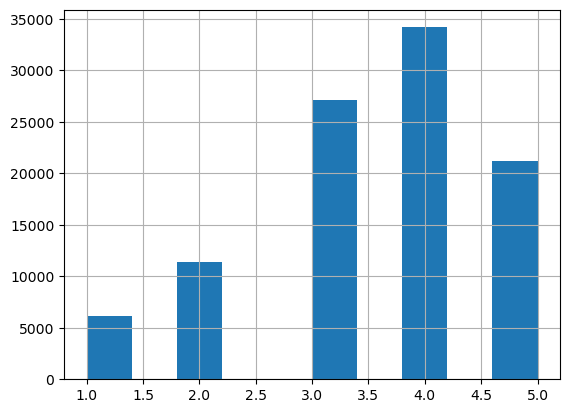

In [25]:
ratings['rating'].hist()

### most active users

In [27]:
ratings['user_id'].value_counts().head()

user_id
405    737
655    685
13     636
450    540
276    518
Name: count, dtype: int64

### most popular movies

In [36]:
data = pd.merge(ratings, movies, on='movie_id')

In [37]:
#most rated movies(popular by number of ratinbgs)

data.groupby('title').count()['rating'] \
    .sort_values(ascending=False)

title
Star Wars (1977)                      583
Contact (1997)                        509
Fargo (1996)                          508
Return of the Jedi (1983)             507
Liar Liar (1997)                      485
                                     ... 
Great Day in Harlem, A (1994)           1
Other Voices, Other Rooms (1997)        1
Good Morning (1971)                     1
Girls Town (1996)                       1
Á köldum klaka (Cold Fever) (1994)      1
Name: rating, Length: 1664, dtype: int64

In [38]:
# top 10 most popular movie

data.groupby('title').count()['rating'] \
    .sort_values(ascending=False) \
    .head(10)

title
Star Wars (1977)                 583
Contact (1997)                   509
Fargo (1996)                     508
Return of the Jedi (1983)        507
Liar Liar (1997)                 485
English Patient, The (1996)      481
Scream (1996)                    478
Toy Story (1995)                 452
Air Force One (1997)             431
Independence Day (ID4) (1996)    429
Name: rating, dtype: int64

In [39]:
#popular + highly rated

movie_stats = data.groupby('title').agg({
    'rating': ['mean', 'count']
})

In [40]:
movie_stats.columns = ['avg_rating', 'num_ratings']

In [41]:
movie_stats.head()

,avg_rating,num_ratings
title,,
'Til There Was You (1997),2.333333,9
1-900 (1994),2.600000,5
101 Dalmatians (1996),2.908257,109
12 Angry Men (1957),4.344000,125
187 (1997),3.024390,41


### avergae movie artings


In [31]:
ratings.groupby('movie_id')['rating'].mean()

movie_id
1       3.878319
2       3.206107
3       3.033333
4       3.550239
5       3.302326
          ...   
1678    1.000000
1679    3.000000
1680    2.000000
1681    3.000000
1682    3.000000
Name: rating, Length: 1682, dtype: float64

## User Demographics

<Axes: >

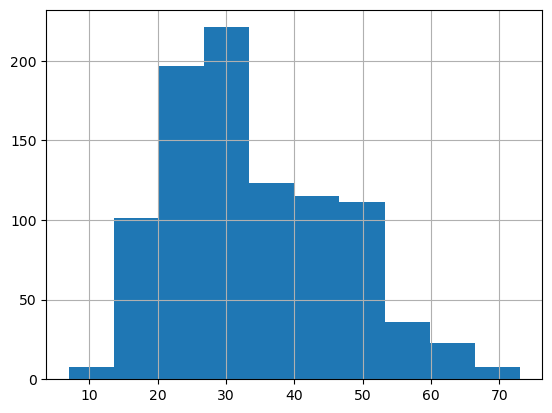

In [32]:
# age distribution

users['age'].hist()

#to know are users mostly young or adults or older gen

In [34]:
# gender distribution

users['gender'].value_counts()

gender
M    670
F    273
Name: count, dtype: int64

In [35]:
# occupation analysis

#which professions use MOvieLens most?

users['occupation'].value_counts()

occupation
student          196
other            105
educator          95
administrator     79
engineer          67
programmer        66
librarian         51
writer            45
executive         32
scientist         31
artist            28
technician        27
marketing         26
entertainment     18
healthcare        16
retired           14
lawyer            12
salesman          12
none               9
homemaker          7
doctor             7
Name: count, dtype: int64

## getting most common genre

In [45]:
movies = pd.read_csv(
    "ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    header=None
)

In [46]:
movie_cols = [
    "movie_id","title","release_date","video_release_date",
    "imdb_url","unknown","Action","Adventure","Animation",
    "Children","Comedy","Crime","Documentary","Drama",
    "Fantasy","FilmNoir","Horror","Musical","Mystery",
    "Romance","SciFi","Thriller","War","Western"
]

movies.columns = movie_cols

### select genre columns

In [47]:
genre_cols=movie_cols[5:]

In [48]:
print(genre_cols)

['unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'FilmNoir', 'Horror', 'Musical', 'Mystery', 'Romance', 'SciFi', 'Thriller', 'War', 'Western']


In [49]:
# count movies in each genre

genre_counts=movies[genre_cols].sum()

In [50]:
#most common genre

genre_counts.sort_values(ascending=False).head(10)

Drama        725
Comedy       505
Action       251
Thriller     251
Romance      247
Adventure    135
Children     122
Crime        109
SciFi        101
Horror        92
dtype: int64

In [53]:
#least common scores

genre_counts.sort_values().head()

#genre_counts.idxmin() -->will give only unknown as output

unknown       2
Fantasy      22
FilmNoir     24
Western      27
Animation    42
dtype: int64

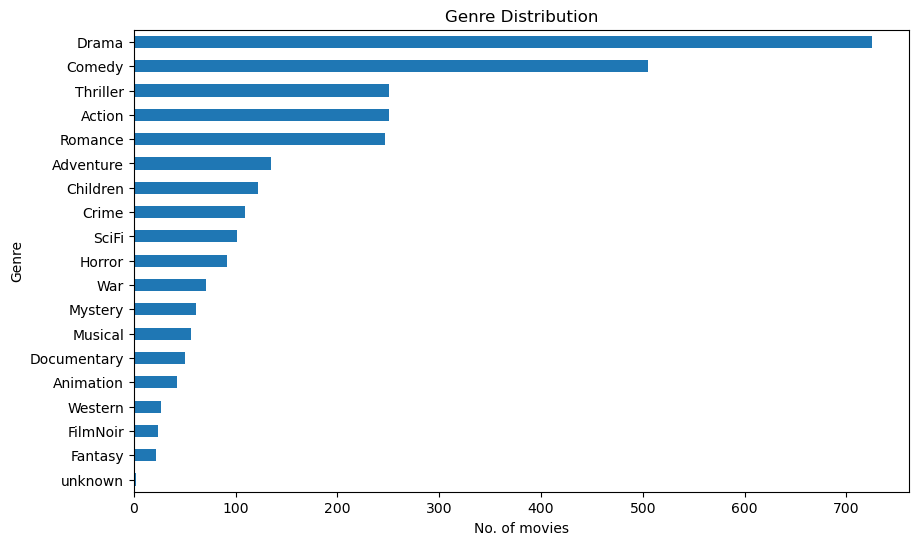

In [54]:
#visualise

import matplotlib.pyplot as plt

genre_counts.sort_values().plot(kind='barh',figsize=(10,6))
plt.xlabel("No. of movies")
plt.ylabel('Genre')
plt.title('Genre Distribution')
plt.show()

In [58]:
#saving for future notebooks

df.to_parquet('data/interim/master.parquet',index=False)

print("Saved successfully")

Saved successfully
